<a href="https://colab.research.google.com/github/kabirmuwal/Academic-Projects/blob/main/Heart_Disease_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **HEALTHCARE SECTOR: CARDIOVASCULAR DISEASE DETECTOR WITH THE USE OF NEURAL NETWORKS**

**TABLE OF CONTENT:**

**1. INTRODCUTION AND PROBLEM STATEMENT**

**2. CODING PHASE**
  
  **2.1 IMPORTING THE LIBRARIES**

  **2.2 UPLOADING THE DATA SET AND EXPLORATION**
   
  **2.3 DATA PREPROCESSING**
   
  **2.4 BUILDING OUR NEURAL NETWORK PIPELINE**
   
  **2.5 EVALUATING THE MODEL ON TEST SET AND VALIDAITON**

**3. SUMMARY**

**INTRODCUTION AND PROBLEM STATEMENT:**

Cardiovascular diesease or CVDs have been traumatising the world for many years and has caused many deaths till now. Most people don't even realise it. Most common cause is the heart failure. In todays growing world with the use of technology and previous stacks and reports it would become eaiser for doctors to detect and diagnose such a problem at an early stage and will help the world to take care of such problems before it gets too serious. With the use of Neural networks and machine learning it would become much easier. Let us begin creating such a model to have a good impact on the healthcare sector for the betterment of the world.

**STEP 2.1: IMPORTING THE LIBRARIES**

I'll be using the basic libraries in machine learning such as pandas, numpy, seaborn and matplot to read the dataset and visualise the dataset that we have for a better understanding. Then with the use of sckit-learn, tensorflow and Keras we will pre-process the data and evaluate the advanced neural network model and evaluate the models accuracy and precision.


In [ ]:
import pandas as ps
import numpy as ny
import seaborn as ss
import matplotlib.pyplot as pypt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


**STEP 2.2: UPLOADING THE DATA SET AND EXPLORATION**

In [ ]:
# Uploading the dataset
df_CVD = ps.read_csv('heart.csv')
print(df_CVD.head())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [ ]:
# Exploring the dataset
print(df_CVD.info())
print(df_CVD.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  1

>> We can see that our dataset consists of multiple factors which accumulate to the heart disease such as:
* Age: Patients Age
* Sex: Male or Female
* Chest pain type: Patient is experiencing what level of pain such as typical agina, atypical agina, non-aginal pain or asymptomatic pain     
* Resting BP: Blood pressure of the patient
* Cholesterol: Cholestrol level of the patient      
* Fasting BS: Patients need to fast before there tests and afterwords there blood sugar level is checked in accordance with that        
* Resting ECG: It refers to electrocardiogram test   
* Max HR: Heart rate of the patient      
* Exercise Angina: The pain caused in chest is because of the exercises or not    
* Old peak: It is the ST depression of patient doing exercise with respect to resting stage      
* ST Slope: The slope of ST segment when the patient is exercising at his/her peak      
* Heart Disease: It is used to check if the patient suffers from heart disease or not    




In [ ]:
# Checking for any null values
print(df_CVD.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


>> The dataset seem clean so let's proceed further with data exploration

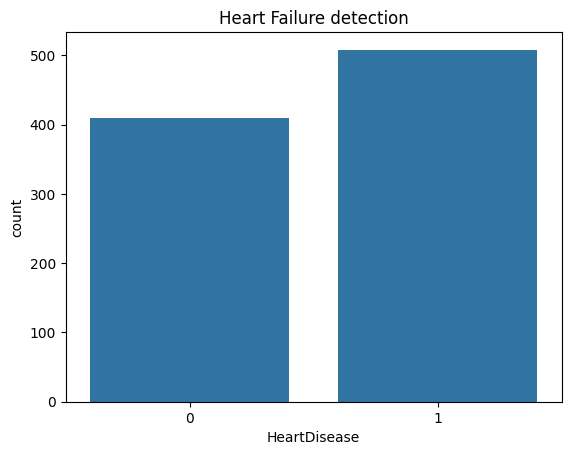

In [ ]:
# Visualising the dataset
ss.countplot(x='HeartDisease', data=df_CVD)
pypt.title('Heart Failure detection')
pypt.show()


From the above bar graph we can see that approximately 400+ patients don't have a heart disease whereas approximately 500+ have a hearty disease.

**STEP 2.3: DATA PREPROCESSING**

As we have explored the data let us preprocess the data before implemention of our model. Firstly let's split the data into 90:10 for training and testing. Then we will proceed with advanced neural networks for validation by using a small portion of our training data set

In [ ]:
# Spilliting of the dataset
A = df_CVD.drop('HeartDisease', axis=1)
B = df_CVD['HeartDisease']

In [ ]:
# Analysing the data set and separating them as  numerical and category columns
category_columns = ['ChestPainType', 'ExerciseAngina', 'RestingECG','Sex', 'ST_Slope']
numerical_columns = ['Age', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak','RestingBP']

In [ ]:
# Preprocessing and using OneHotEncoder to convert category column into Binary format
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), numerical_columns),
        ('category', OneHotEncoder(drop='first'), category_columns)
    ]
)


In [ ]:
# Data is being splitted into train and test
A_train, A_test, B_train, B_test = train_test_split(A, B, test_size=0.1, random_state=42, stratify=B)

In [ ]:
# We will use our preprocessed pipeline to our training dataset
A_train_transformed = preprocessor.fit_transform(A_train)
A_test_transformed = preprocessor.transform(A_test)

**STEP 2.4: BUILDING OUR NEURAL NETWORK PIPELINE**

As we know neural network comprises of input layer, hidden layers and  output layer. We would use io_dim to identify the features in our prepossesed data, for non-linearity we have relu as a hidden layer and sigmoid as our output layer. Then we simply compile our model.


In [ ]:
def creationofmodel(io_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=io_dim),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model



Dimensions of the input layer

In [ ]:
io_dim = A_train_transformed.shape[1]
io_dim

15

Creating the model

In [ ]:
model = creationofmodel(io_dim)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fitting Model to the Data

In [ ]:
hist = model.fit(A_train_transformed, B_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)


Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4693 - loss: 0.7174 - val_accuracy: 0.7530 - val_loss: 0.6181
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7843 - loss: 0.5893 - val_accuracy: 0.7831 - val_loss: 0.5400
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8257 - loss: 0.4976 - val_accuracy: 0.7831 - val_loss: 0.4902
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8662 - loss: 0.4008 - val_accuracy: 0.7831 - val_loss: 0.4809
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8770 - loss: 0.3549 - val_accuracy: 0.7831 - val_loss: 0.4908
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8584 - loss: 0.3502 - val_accuracy: 0.7892 - val_loss: 0.4922
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8572 - loss: 0.3472 - val_accuracy: 0.7952 - val_loss: 0.4945
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8734 - loss: 0.2989 - val_accuracy: 0.7892 - val_loss

In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                     │ (None, 64)                  │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,413 (36.77 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,276 (24.52 KB)

**Visualization:**

Before we go ahead let us Visualize the accuracy and loss after running the epochs

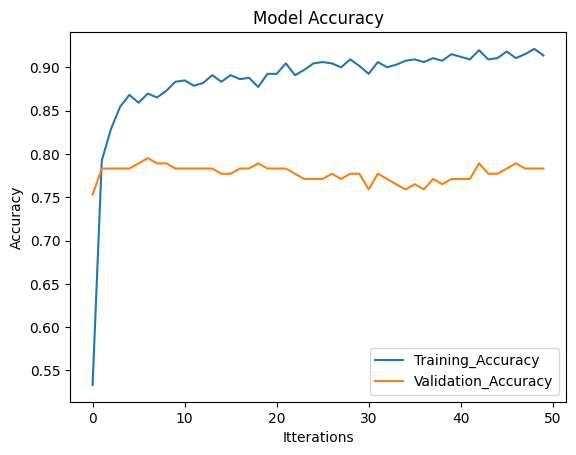

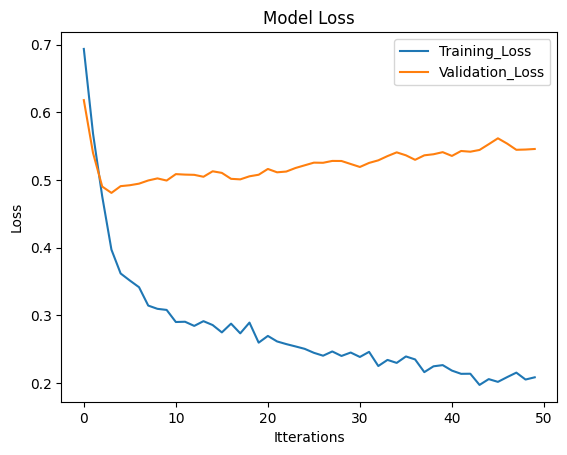

In [ ]:
# Plot for accuracy in training & Validation dataset
pypt.plot(hist.history['accuracy'], label='Training_Accuracy')
pypt.plot(hist.history['val_accuracy'], label='Validation_Accuracy')
pypt.title('Model Accuracy')
pypt.xlabel('Itterations')
pypt.ylabel('Accuracy')
pypt.legend()
pypt.show()

# Plot for loss in training and validation dataset
pypt.plot(hist.history['loss'], label='Training_Loss')
pypt.plot(hist.history['val_loss'], label='Validation_Loss')
pypt.title('Model Loss')
pypt.xlabel('Itterations')
pypt.ylabel('Loss')
pypt.legend()
pypt.show()


**STEP 2.5: EVALUATING THE MODEL ON TEST SET AND VALIDAITON**

After getting suitable results after training our  dataset we will evaluate and test it for our test dataset and get results for our model making sure it runs smoothly and evaluation the overall model by checking the accuracy, precision, recall & f-1 score making our predictions to be accurate for future instance.

In [ ]:
loss, accuracy = model.evaluate(A_test_transformed, B_test, verbose=0)
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 0.91


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
B_pred = (model.predict(A_test_transformed) > 0.5).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step 


In [ ]:
print(confusion_matrix(B_test, B_pred))

[[39  2]
 [ 6 45]]


**From the above confusion Matrix we can see the predictions of our model are as follow:**

**CLASS 0**
*   **True Negative (39)| Correct Prediction:** We have 39 patients that don't have  a heart disease
*   **False Positive (2)| Incorrect Prediction:** We have 2 patients having a heart disease but in actual they don't

**CLASS 1**
*   **False Negative (6)| Inorrect Prediction:** We have 6 patients that don't have a  heart disease when they actually do
*   **True Positive (45)| Correct Prediction:** We have 45 patients that have heart disease


In [ ]:
print(classification_report(B_test, B_pred))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91        41
           1       0.96      0.88      0.92        51

    accuracy                           0.91        92
   macro avg       0.91      0.92      0.91        92
weighted avg       0.92      0.91      0.91        92



**We get the following results for our Model:**

**Overall Accuracy: 91.00%**

**CLASS 0:**

Precision: 87.00 %

Recall: 95.00 %

F1-Score: 91.00 %

**CLASS 1:**

Precision: 96.00 %

Recall: 88.00 %

F1-Score 92.00 %

Hence, Our model works fine for detecting weather the patient has a heart and also if they don't have a heart disease.

# **SUMMARY:**

1. I have developed a model using deep neural networks which has helped us to get high accuracy in predicting the heart failure.
2. The use of one-hot encoding and scaling has helped us to reduce overfitting.


**Refrence for open source data set:** https://www.kaggle.com/code/calebreigada/neural-network-heart-failure-detection-100-recall/notebook

Also I am attaching a image when I splitted that data set into 80:20 because while submitting I was getting unnecessary similarity score for my work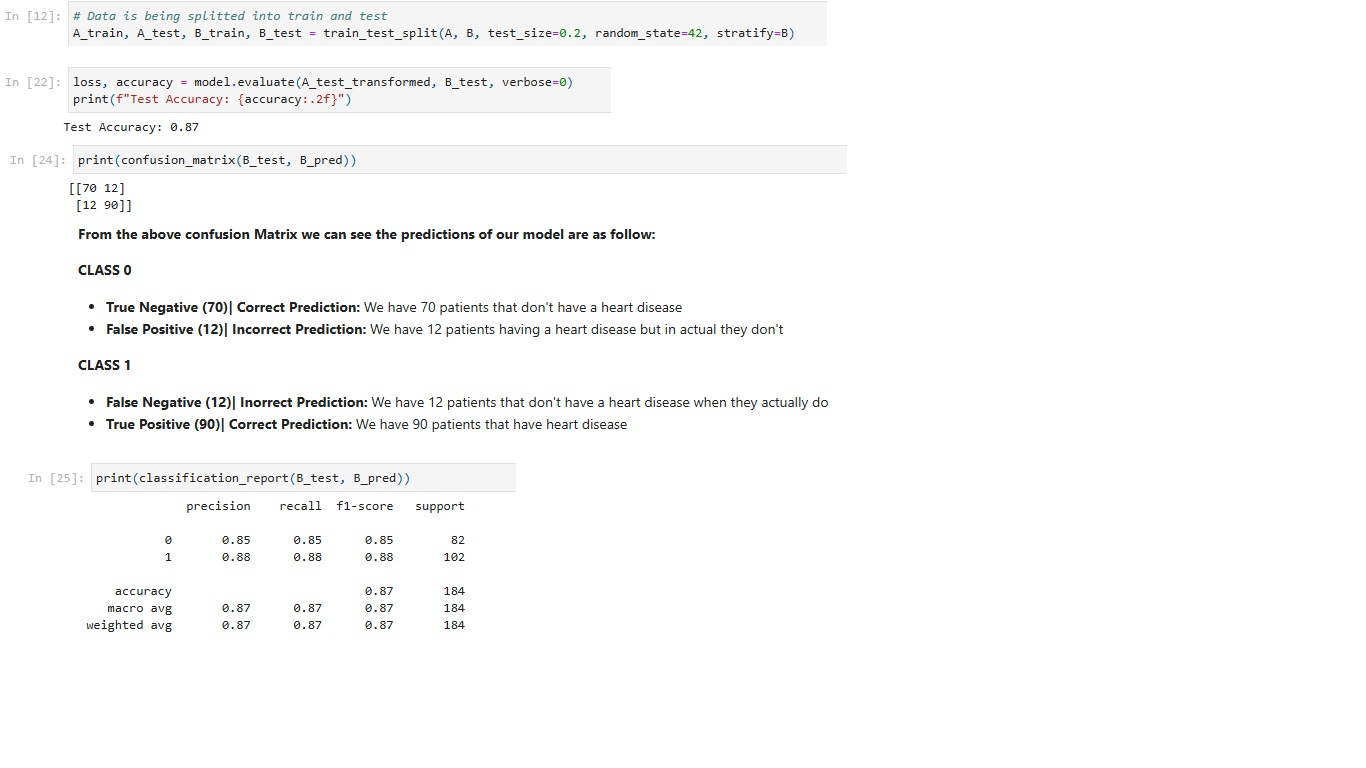